# Notebook 05 — Fingerprints & Similarity: How Computers Compare Molecules

When a medicinal chemist says "these two look similar," they're doing an intuitive pattern comparison — scanning for shared scaffolds, functional groups, ring systems, and overall shape. You might glance at aspirin and salicylic acid and immediately say "same core."

**Molecular fingerprints formalize this intuition into bit-vector representations that computers can compare at scale.** Instead of relying on a chemist's visual pattern-matching (which doesn't scale to millions of compounds), we encode each molecule's structural features into a fixed-length vector and use mathematical similarity metrics to quantify "how alike" two molecules are.

This notebook covers:
1. What fingerprints are and why they matter
2. The major fingerprint types (Morgan/ECFP, MACCS, RDKit, Atom Pair, Topological Torsion)
3. Similarity metrics (Tanimoto, Dice)
4. Building similarity matrices and finding nearest neighbors

In [1]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Draw, MACCSkeys, rdMolDescriptors
from rdkit.Chem import rdFingerprintGenerator
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


## What Is a Molecular Fingerprint?

**Wet-lab analogy:** Imagine you have a checklist for characterizing a compound — "aromatic ring? yes/no", "carboxylic acid? yes/no", "halogen present? yes/no", and so on for hundreds of features. After filling it out, you have a binary vector that summarizes the molecule's structural features. That's essentially a molecular fingerprint.

A molecular fingerprint encodes structural features as a **fixed-length bit vector** (or count vector). Each position in the vector corresponds to a particular substructural feature:

- **Bit vectors** (binary): each bit is 0 or 1 — the feature is absent or present. Fast, compact, and the most common representation.
- **Count vectors**: each position stores an integer — how many times that feature appears. More informative but larger.

**Why fixed-length?** Machine learning algorithms and similarity calculations need vectors of uniform dimension. Fingerprints give us exactly that, regardless of whether the molecule has 5 atoms or 500.

## Morgan / ECFP Fingerprints

**Chemistry refresher:** Morgan fingerprints are the computational equivalent of Extended-Connectivity Fingerprints (ECFP), the most widely used fingerprint in cheminformatics. They work by a beautifully intuitive algorithm:

1. **Start at each atom** — assign an initial identifier based on atomic properties (element, degree, charge, etc.)
2. **Expand outward** — at each iteration, incorporate information from neighboring atoms
3. **Repeat for `radius` steps** — radius=2 means each atom "sees" its environment out to 2 bonds away

The result captures **local chemical context**: hybridization state, functional groups, ring membership, and neighboring substituents — much like how a chemist mentally evaluates an atom's environment.

**Naming convention:**
- **Radius=2** → **ECFP4** (diameter = 2 × radius = 4)
- **Radius=3** → **ECFP6**

ECFP4 is the workhorse of virtual screening and QSAR modeling. ECFP6 captures broader context but at the cost of more bit collisions in the hashed representation.

In [2]:
# Generate Morgan fingerprint using the modern generator API
mol = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")  # aspirin

# ECFP4 (radius=2, 2048 bits)
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fp = morgan_gen.GetFingerprint(mol)

print(f"Fingerprint length: {fp.GetNumBits()}")
print(f"Bits set (on):      {fp.GetNumOnBits()}")
print(f"Density:            {fp.GetNumOnBits() / fp.GetNumBits():.3f}")

# Get the on-bit positions
on_bits = list(fp.GetOnBits())
print(f"First 20 on-bits:   {on_bits[:20]}")

Fingerprint length: 2048
Bits set (on):      24
Density:            0.012
First 20 on-bits:   [389, 456, 650, 695, 807, 909, 1017, 1035, 1047, 1057, 1088, 1199, 1380, 1410, 1447, 1468, 1616, 1729, 1750, 1775]


In [3]:
# Count vector version — captures multiplicity of substructures
count_fp = morgan_gen.GetCountFingerprint(mol)
non_zero = count_fp.GetNonzeroElements()
print(f"Non-zero elements: {len(non_zero)}")
print(f"Sample: {dict(list(non_zero.items())[:5])}")

Non-zero elements: 24
Sample: {389: 1, 456: 1, 650: 2, 695: 1, 807: 3}


## MACCS Keys

**Chemistry refresher:** While Morgan fingerprints are algorithmically generated (hashed), MACCS keys take a completely different approach: they are a **curated set of 166 predefined structural patterns** — a checklist hand-crafted by experienced chemists.

Think of it as a standardized form where each question is specific:
- Bit 125: "Is there an aromatic ring?"
- Bit 139: "Is there a nitrogen in a ring?"
- Bit 160: "Is there an OH group?"

This makes MACCS keys **interpretable** — you can look at which bits are on and know exactly what substructure was detected. The tradeoff: with only 166 bits, they capture less detail than a 2048-bit Morgan fingerprint, but they're excellent for quick structural categorization and have historical significance in pharma databases.

In [4]:
fp_maccs = MACCSkeys.GenMACCSKeys(mol)
print(f"MACCS length: {fp_maccs.GetNumBits()}")
print(f"Bits on:      {fp_maccs.GetNumOnBits()}")
on_bits = list(fp_maccs.GetOnBits())
print(f"On bits: {on_bits}")

MACCS length: 167
Bits on:      21
On bits: [89, 113, 123, 126, 127, 136, 139, 140, 143, 144, 146, 150, 152, 154, 157, 159, 160, 162, 163, 164, 165]


## RDKit Fingerprint, Atom Pairs & Topological Torsions

Different fingerprint types capture different structural perspectives — much like how IR, NMR, and mass spec each reveal different aspects of a molecule:

| Fingerprint | Approach | Analogy |
|---|---|---|
| **Morgan/ECFP** | Circular neighborhoods around each atom | "What does the local environment look like?" |
| **RDKit FP** | Linear paths through the molecular graph (Daylight-like) | "What connected chains of atoms exist?" |
| **Atom Pairs** | Pairs of atoms + shortest path distance between them | "What atom types are N bonds apart?" |
| **Topological Torsion** | Sequences of 4 consecutively bonded non-hydrogen atoms | "What 4-atom backbone fragments exist?" |

**Path-based fingerprints** (RDKit FP) and **circular fingerprints** (Morgan) provide complementary views. In practice, Morgan fingerprints dominate, but combining multiple fingerprint types can improve ML model performance.

In [5]:
# RDKit fingerprint (path-based, Daylight-like)
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(fpSize=2048)
fp_rdkit = rdkit_gen.GetFingerprint(mol)
print(f"RDKit FP bits on: {fp_rdkit.GetNumOnBits()}")

# Atom pair fingerprint
ap_gen = rdFingerprintGenerator.GetAtomPairGenerator(fpSize=2048)
fp_ap = ap_gen.GetFingerprint(mol)
print(f"Atom pair bits on: {fp_ap.GetNumOnBits()}")

# Topological torsion fingerprint
tt_gen = rdFingerprintGenerator.GetTopologicalTorsionGenerator(fpSize=2048)
fp_tt = tt_gen.GetFingerprint(mol)
print(f"Topo torsion bits on: {fp_tt.GetNumOnBits()}")

RDKit FP bits on: 354
Atom pair bits on: 68
Topo torsion bits on: 18


## Similarity Metrics

**Chemistry refresher:** Once we have fingerprints, we need a way to quantify "how similar" two molecules are. The **Tanimoto coefficient** (also called Jaccard index) is the gold standard:

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

For bit vectors: count the bits that are ON in **both** A and B, divide by the bits that are ON in **either** A or B.

- **T = 1.0**: identical fingerprints (all the same bits are set)
- **T = 0.0**: nothing in common (no shared bits)

The **Dice coefficient** is a related metric that weights shared bits more heavily:

$$D(A, B) = \frac{2|A \cap B|}{|A| + |B|}$$

Dice is always >= Tanimoto for the same pair. Both are valid; Tanimoto is more widely used in cheminformatics by convention.

**SAR cliffs warning:** Structurally similar molecules (high Tanimoto) can have very different biological activity — these "activity cliffs" are critically important in drug discovery. A single methyl group or stereocenter change can flip a compound from active to inactive.

In [6]:
# Compare two molecules — aspirin vs ibuprofen
aspirin = Chem.MolFromSmiles("CC(=O)OC1=CC=CC=C1C(=O)O")
ibuprofen = Chem.MolFromSmiles("CC(C)CC1=CC=C(C=C1)C(C)C(=O)O")

fp1 = morgan_gen.GetFingerprint(aspirin)
fp2 = morgan_gen.GetFingerprint(ibuprofen)

tanimoto = DataStructs.TanimotoSimilarity(fp1, fp2)
dice = DataStructs.DiceSimilarity(fp1, fp2)
print(f"Aspirin vs Ibuprofen")
print(f"  Tanimoto: {tanimoto:.3f}")
print(f"  Dice:     {dice:.3f}")

Aspirin vs Ibuprofen
  Tanimoto: 0.195
  Dice:     0.327


### Similarity Matrix: Comparing a Panel of NSAIDs

Let's build a full pairwise similarity matrix for a set of well-known NSAIDs (Non-Steroidal Anti-Inflammatory Drugs). As a chemist, you know these all inhibit COX enzymes — but their structures vary quite a bit. Let's see how the fingerprints capture that.

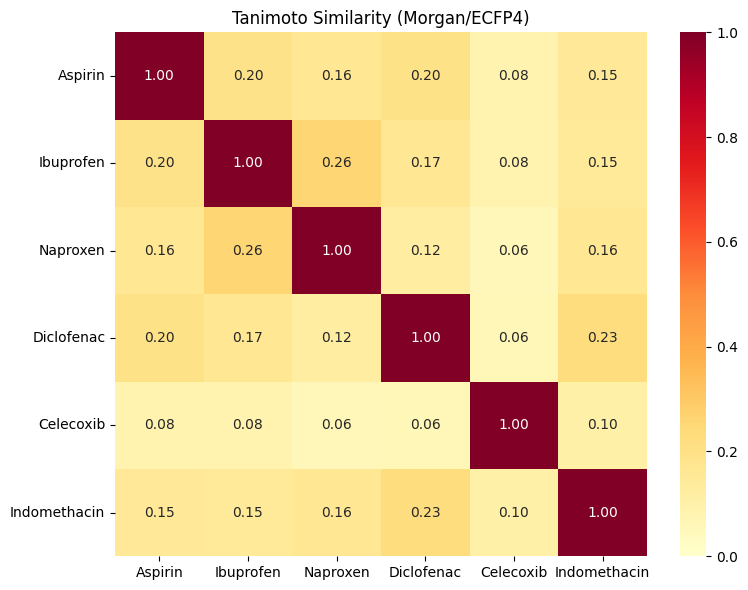

In [7]:
nsaids = {
    "Aspirin":     "CC(=O)OC1=CC=CC=C1C(=O)O",
    "Ibuprofen":   "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",
    "Naproxen":    "COC1=CC2=CC(=CC2=CC1)C(C)C(=O)O",
    "Diclofenac":  "OC(=O)CC1=CC=CC=C1NC1=C(Cl)C=CC=C1Cl",
    "Celecoxib":   "CC1=CC=C(C=C1)C1=CC(=NN1C1=CC=C(C=C1)S(N)(=O)=O)C(F)(F)F",
    "Indomethacin":"COC1=CC2=C(C=C1)C(=C(CC(=O)O)N2C(=O)C1=CC=C(Cl)C=C1)C",
}

names = list(nsaids.keys())
fps = [morgan_gen.GetFingerprint(Chem.MolFromSmiles(smi)) for smi in nsaids.values()]

# Build pairwise similarity matrix
n = len(fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

df_sim = pd.DataFrame(sim_matrix, index=names, columns=names)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_sim, annot=True, fmt=".2f", cmap="YlOrRd", vmin=0, vmax=1, ax=ax)
ax.set_title("Tanimoto Similarity (Morgan/ECFP4)")
plt.tight_layout()
plt.show()

## Bulk Similarity & Nearest Neighbors

In real virtual screening, you're comparing a query molecule against millions of candidates. RDKit's `BulkTanimotoSimilarity` is optimized for this one-vs-many pattern — much faster than looping through individual comparisons.

In [8]:
# BulkTanimotoSimilarity — efficient one-vs-many comparison
query_fp = fps[0]  # Aspirin as the query
similarities = DataStructs.BulkTanimotoSimilarity(query_fp, fps)

print("Similarity to Aspirin (ranked):")
print("-" * 35)
for name, sim in sorted(zip(names, similarities), key=lambda x: -x[1]):
    bar = "#" * int(sim * 30)
    print(f"  {name:15s} {sim:.3f}  {bar}")

Similarity to Aspirin (ranked):
-----------------------------------
  Aspirin         1.000  ##############################
  Diclofenac      0.196  #####
  Ibuprofen       0.195  #####
  Naproxen        0.163  ####
  Indomethacin    0.150  ####
  Celecoxib       0.085  ##


### Practical Similarity Thresholds

Rules of thumb for Tanimoto similarity (fingerprint-type dependent, but generally useful):

| Tanimoto Range | Interpretation |
|---|---|
| **> 0.85** | Very similar — likely share a core scaffold |
| **0.7 – 0.85** | Similar — related chemical series |
| **0.5 – 0.7** | Moderate — some shared features |
| **< 0.5** | Quite different — limited structural overlap |

**Caveat:** These thresholds depend heavily on the fingerprint type and size. MACCS keys tend to give higher similarity values than Morgan fingerprints for the same pair of molecules (fewer, broader bits). Always calibrate your thresholds to your specific fingerprint and dataset.

## Summary

**What we covered:**

| Fingerprint | Key Idea | Typical Use |
|---|---|---|
| **Morgan / ECFP** | Circular atom environments | Virtual screening, QSAR, ML features |
| **MACCS Keys** | 166 predefined structural patterns | Quick categorization, interpretable comparisons |
| **RDKit FP** | Path-based (Daylight-like) | General similarity, scaffold-aware |
| **Atom Pairs** | Atom-type pairs + distance | Pharmacophore-like comparisons |
| **Topological Torsion** | 4-atom backbone fragments | Capturing connectivity patterns |

**Key takeaways:**
1. Fingerprints translate molecular structure into fixed-length vectors that enable computational comparison at scale
2. Tanimoto similarity is the standard metric — but threshold interpretation depends on the fingerprint type
3. Different fingerprint types capture different structural perspectives — choose based on your task (or combine them)
4. `BulkTanimotoSimilarity` enables efficient one-vs-many searches for virtual screening

**Up next (Notebook 06):** We'll use these fingerprints as features for machine learning — building QSAR models that predict biological activity from molecular structure.